<a href="https://colab.research.google.com/github/HISATAKA-KATO/EU_M_Math-Repository/blob/main/Chap03_Cm_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
#今回利用するライブラリ
import numpy as np
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

#可視化ライブラリ
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style()
%matplotlib inline

#zipダウンロードライブラリ
import requests, zipfile
from io import StringIO
import io

In [23]:

# データの読み込み
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

r = requests.get(url, stream=True)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

student_data_math = pd.read_csv('student-mat.csv', sep=';')

# 必要な列だけ取り出す
# sex: 性別, G1: 一期目の数学成績
df = student_data_math[['sex', 'G1']].copy()

# 男女別に一期目の数学成績 G1 を昇順に並べ替え
df_sorted = df.sort_values(['sex', 'G1'], ascending=[True, True])

# 確認用
print(df_sorted.head())

    sex  G1
137   F   4
0     F   5
1     F   5
79    F   5
4     F   6


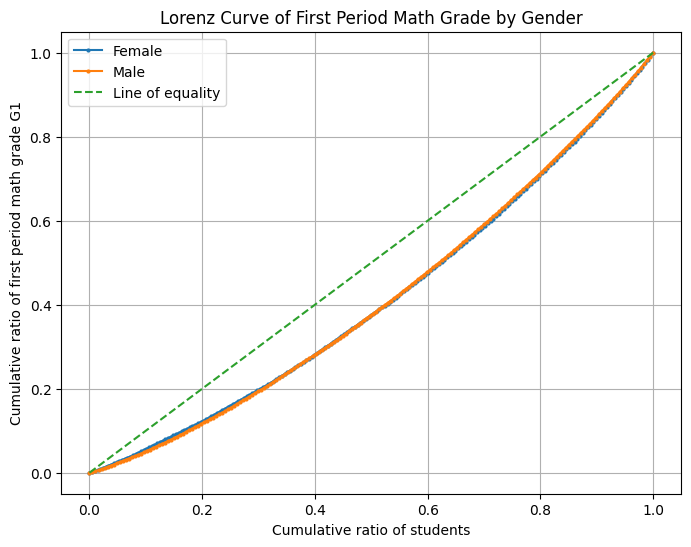

In [24]:
def lorenz_curve(data, value_col):
    """
    ローレンツ曲線用の
    横軸：人数の累積比率
    縦軸：値の累積比率
    を計算する関数
    """
    values = np.sort(data[value_col].values)  # 昇順に並べ替え

    cum_values = np.cumsum(values)  # 成績の累積和
    cum_values = np.insert(cum_values, 0, 0)  # 原点 0 を追加

    cum_value_ratio = cum_values / cum_values[-1]  # 成績の累積比率

    cum_people_ratio = np.arange(0, len(values) + 1) / len(values)  # 人数の累積比率

    return cum_people_ratio, cum_value_ratio


plt.figure(figsize=(8, 6))

# 女子 F
female_data = df[df['sex'] == 'F']
x_f, y_f = lorenz_curve(female_data, 'G1')
plt.plot(x_f, y_f, label='Female', marker='o', markersize=2)

# 男子 M
male_data = df[df['sex'] == 'M']
x_m, y_m = lorenz_curve(male_data, 'G1')
plt.plot(x_m, y_m, label='Male', marker='o', markersize=2)

# 完全平等線
plt.plot([0, 1], [0, 1], linestyle='--', label='Line of equality')

plt.xlabel('Cumulative ratio of students')
plt.ylabel('Cumulative ratio of first period math grade G1')
plt.title('Lorenz Curve of First Period Math Grade by Gender')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#ジニ係数を計算する関数
def gini_coefficient(values):
    values = np.array(values, dtype=float)

    n = len(values)
    x_bar = values.mean()

    # 平均が0の場合は計算できないので0を返す
    if x_bar == 0:
        return 0

    # xi - xj を全組み合わせで計算
    diff_matrix = np.abs(values[:, None] - values[None, :])

    # ΣiΣj |xi - xj|
    total_diff = diff_matrix.sum()

    # GI = ΣiΣj |xi - xj| / (2 * n^2 * x_bar)
    GI = total_diff / (2 * n**2 * x_bar)

    return GI

In [26]:
result = pd.DataFrame({
    '性別': ['女性', '男性'],
    'ジニ係数': [
        gini_by_sex['F'],
        gini_by_sex['M']
    ]
})

print(result)

   性別      ジニ係数
0  女性  0.172378
1  男性  0.171974
